# Mrk 421 Fermi-LAT 官方 weekly 光变整理版

本 notebook 负责从官方 weekly light curve 中提取可用于 QPO 搜索的 Fermi 输入，并与 WCDA 时段对齐后给出 CWT 与 WWZ 的快速检查。

原始探索版本已归档至 `archive/notebooks/mkn421_fermi_weekly_raw_20260320.ipynb`。

In [1]:

from pathlib import Path

def locate_project_root(*markers):
    candidates = [
        Path.cwd().resolve(),
        Path.cwd().resolve().parent,
        Path('/home/server/projects/QPO'),
        Path('/mnt/mydisk/server/projects/PQO'),
    ]
    for cand in candidates:
        if all((cand / marker).exists() for marker in markers):
            return cand
    raise FileNotFoundError(f'Cannot locate project root for markers: {markers}')

PROJECT_ROOT = locate_project_root('mkn421_lhaaso/Mrk421_604800.lc')
FERMI_LC_PATH = PROJECT_ROOT / 'mkn421_lhaaso' / 'Mrk421_604800.lc'
OUT_CSV = PROJECT_ROOT / 'mkn421_lhaaso' / 'Mrk421_Fermi_weekly_TSge9_MJD.csv'

print('PROJECT_ROOT =', PROJECT_ROOT)
print('FERMI_LC_PATH =', FERMI_LC_PATH)


PROJECT_ROOT = /mnt/mydisk/server/projects/PQO
FERMI_LC_PATH = /mnt/mydisk/server/projects/PQO/mkn421_lhaaso/Mrk421_604800.lc


## 1. 数据读取与 TS 筛选

目标是从官方 `.lc` 文件中提取 TS≥9 的 weekly flux，并保存为后续分析可复用的 CSV。

Total bins        : 901
TS >= 9 bins used : 892


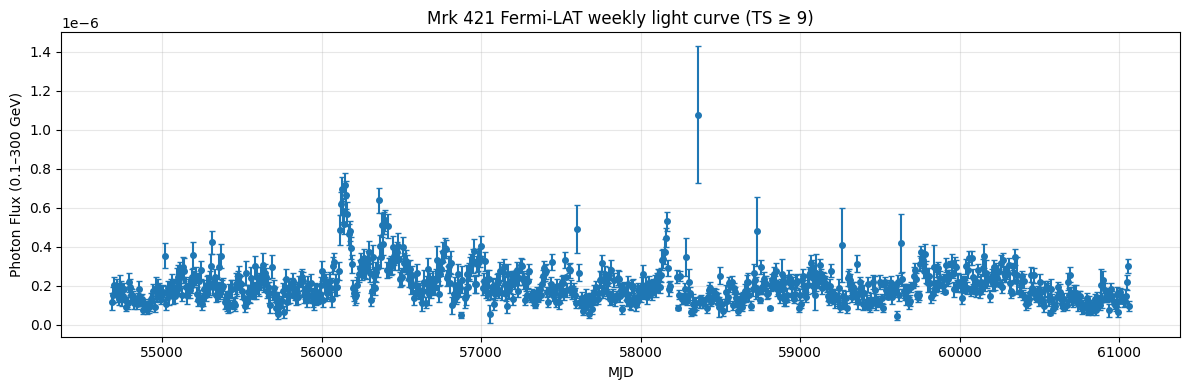

Saved: /mnt/mydisk/server/projects/PQO/mkn421_lhaaso/Mrk421_Fermi_weekly_TSge9_MJD.csv


In [2]:
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.time import Time, TimeDelta
import matplotlib.pyplot as plt

# ===============================
# 1. 读取 FITS light curve
# ===============================
fn = str(FERMI_LC_PATH)

with fits.open(fn) as hdul:
    data = hdul["LIGHTCURVES"].data
    df = pd.DataFrame(np.array(data).byteswap().newbyteorder())

# ===============================
# 2. 取时间中心（MET 秒）
# ===============================
t_mid_met = 0.5 * (df["START"].values + df["STOP"].values)

# ===============================
# 3. MET → MJD
#    Fermi MET = seconds since 2001-01-01 00:00:00 UTC
# ===============================
t0 = Time("2001-01-01T00:00:00", scale="utc")
t_mjd = (t0 + TimeDelta(t_mid_met, format="sec")).mjd

# ===============================
# 4. 取 0.1–300 GeV flux + error + TS
# ===============================
flux = df["FLUX_100_300000"].values
flux_err = df["ERROR_100_300000"].values
ts = df["TEST_STATISTIC"].values

# ===============================
# 5. 剔除 TS < 9 + 基本质量控制
# ===============================
mask = (
    (ts >= 9) &
    np.isfinite(t_mjd) &
    np.isfinite(flux) &
    np.isfinite(flux_err) &
    (flux_err > 0)
)

t_mjd_sel   = t_mjd[mask]
flux_sel   = flux[mask]
flux_err_sel = flux_err[mask]

print(f"Total bins        : {len(df)}")
print(f"TS >= 9 bins used : {len(t_mjd_sel)}")

# ===============================
# 6. 按时间排序（非常重要，给 WWZ / GP 用）
# ===============================
idx = np.argsort(t_mjd_sel)
t_mjd_sel   = t_mjd_sel[idx]
flux_sel   = flux_sel[idx]
flux_err_sel = flux_err_sel[idx]

# ===============================
# 7. 画最终“可用于周期分析”的光变
# ===============================
plt.figure(figsize=(12,4))
plt.errorbar(
    t_mjd_sel, flux_sel, yerr=flux_err_sel,
    fmt="o", ms=4, capsize=2
)
plt.xlabel("MJD")
plt.ylabel(r"Photon Flux (0.1–300 GeV)")
plt.title("Mrk 421 Fermi-LAT weekly light curve (TS ≥ 9)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ===============================
# 8. （可选）保存给后续周期分析用
# ===============================
out = pd.DataFrame({
    "mjd": t_mjd_sel,
    "flux": flux_sel,
    "flux_err": flux_err_sel,
})

out.to_csv(OUT_CSV, index=False)
print(f"Saved: {OUT_CSV}")


## 2. 与 WCDA 共同时段对齐

为了进行 Fermi–WCDA 交叉检查，这里裁剪到 WCDA 当前分析采用的时间窗口（2021-03-08 至 2025-11-06）。

Bins in range: 238


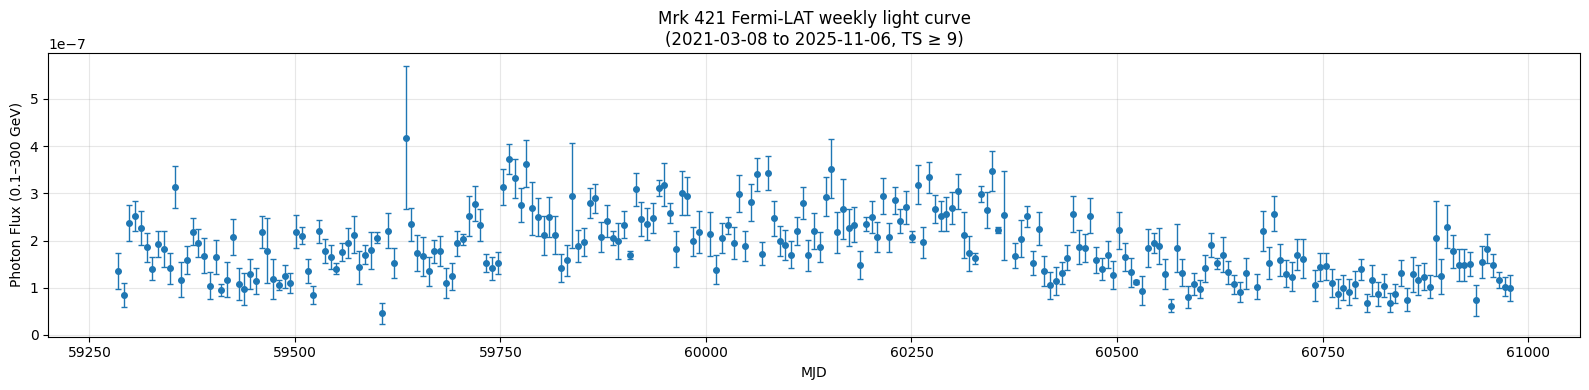

In [3]:
# 提取与WCDA相同的时间数据 2025.030.08--2025.11.06
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time

# ===============================
# 1. 时间范围mask
# ===============================
t_start = Time("2021-03-08T00:00:00", scale="utc").mjd
t_end   = Time("2025-11-06T00:00:00", scale="utc").mjd

mask_time = (t_mjd_sel >= t_start) & (t_mjd_sel <= t_end)

t_cut   = t_mjd_sel[mask_time]
f_cut   = flux_sel[mask_time]
e_cut   = flux_err_sel[mask_time]

print(f"Bins in range: {len(t_cut)}")

# ===============================
# 2. 单独画截取后的光变
# ===============================
plt.figure(figsize=(16,4))
plt.errorbar(
    t_cut, f_cut, yerr=e_cut,
    fmt="o", ms=4, capsize=2,elinewidth=1
)
plt.xlabel("MJD")
plt.ylabel(r"Photon Flux (0.1–300 GeV)")
# plt.yscale("log")
plt.title("Mrk 421 Fermi-LAT weekly light curve\n(2021-03-08 to 2025-11-06, TS ≥ 9)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 3. CWT 快速检查

这一部分给出与 WCDA 共同时段 weekly Fermi 光变的 Morlet CWT 时频图，用于确认候选周期大致出现的时间窗口。

In [4]:
# 进行CWT显著性检验
# 数据t_cut, f_cut, e_cut 已经mask清洗过
# 为了代码一致，重新赋值
t_mjd = t_cut
flux = f_cut
flux_err = e_cut


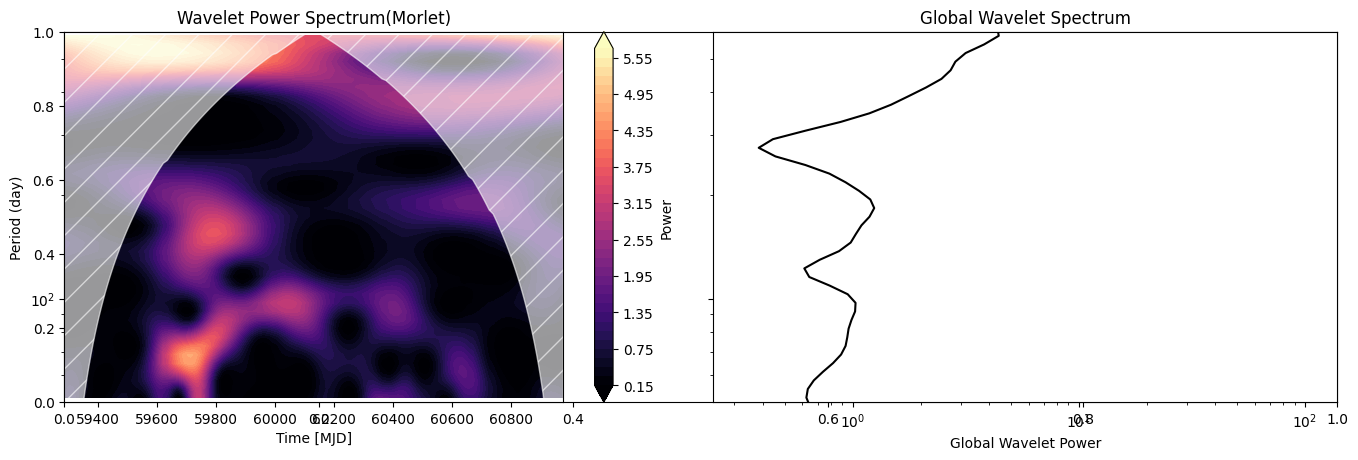

In [5]:
import matplotlib.pyplot as plt
import pycwt as wavelet
import numpy as np

# ==== 数据准备 ====
y = flux - np.mean(flux)
y /= np.std(y)

dt = np.median(np.diff(t_mjd))   # dt=30 day
mother = wavelet.Morlet(6)
dj = 1/12
s0 = 2*dt
J = int(np.log2(len(y)*dt/s0)/dj)

# ==== CWT ====
wave, scales, freqs, coi, fft, fftfreqs = wavelet.cwt(
    y, dt, dj=dj, s0=s0, J=J, wavelet=mother
)

power = np.abs(wave)**2
period = 1/freqs

# ==== Meshgrid ====
T, P = np.meshgrid(t_mjd, period)

# ------------------------------------------------------------------------------
#                              FIGURE
# ------------------------------------------------------------------------------
fig = plt.subplots(figsize=(14, 5))[0]

# ---------------------------------------
# 左图：WPS
# ---------------------------------------
ax1 = fig.add_subplot(121)

Pmin, Pmax = 50, 600
maskP = (period >= Pmin) & (period <= Pmax)

im = ax1.contourf(
    T[maskP, :],
    P[maskP, :],
    power[maskP, :],
    levels=50,
    extend='both',
    cmap='magma'
)

# COI
ax1.fill_between(
    t_mjd,
    Pmax,
    coi, where=(coi <= Pmax),
    color='white',
    alpha=0.6,
    hatch='/'
)

ax1.set_yscale('log')
ax1.set_ylabel("Period (day)")
ax1.set_xlabel("Time [MJD]")
ax1.set_title("Wavelet Power Spectrum(Morlet)")
# 把 y 轴范围限定在实际的 period 范围内
ax1.set_ylim(Pmin, Pmax)

cbar = fig.colorbar(im, ax=ax1)
cbar.set_label("Power")

# ---------------------------------------
# 右图：GWS（共享 y 轴）
# ---------------------------------------
ax2 = fig.add_subplot(122, sharey=ax1)   # ★关键：共享 y 轴！

GWS = np.mean(power, axis=1)

ax2.plot(GWS, period, color='black')

ax2.set_xscale("log")
ax2.set_xlabel("Global Wavelet Power")
ax2.set_title("Global Wavelet Spectrum")

# 避免重复显示左侧 ytick 标签
plt.setp(ax2.get_yticklabels(), visible=False)

plt.tight_layout()
plt.show()


## 4. WWZ 快速检查

WWZ 对不规则采样更稳健，因此这里保留 weekly 光变的 ridge 提取与时频图，作为 CWT 的互证工具。

N=238, Tspan=1694.00 d, dt_med=7.00 d
WWZ settings:
  period range: [50.0, 500.0] d
  freq range:   [0.002, 0.02] 1/d
  freq_step:    2.95159e-05 1/d
  time_divisions: 250
  decay_constant: 0.0125
*** Starting Weighted Wavelet Z-transform ***

adjusted time_divisions to:  238
Pseudo sample frequency (median) is  0.143
largest tau window is  7.148
5.5 seconds has passed to complete Weighted Wavelet Z-transform 



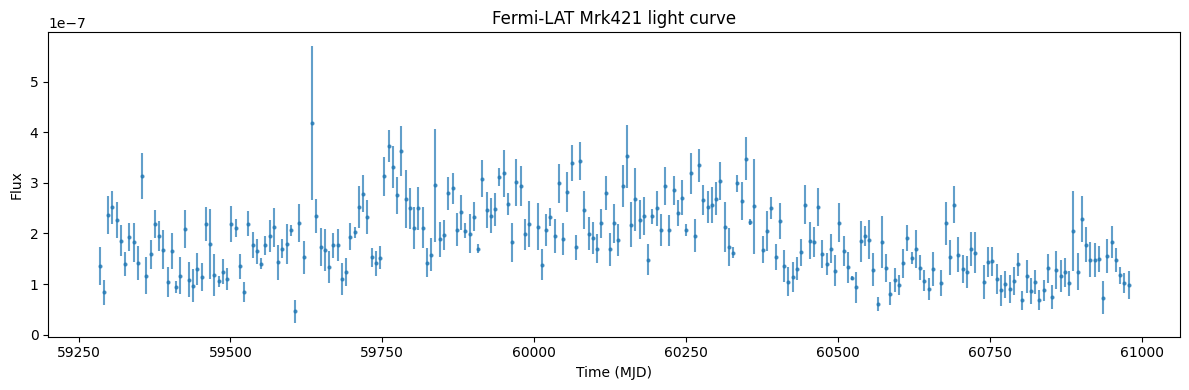

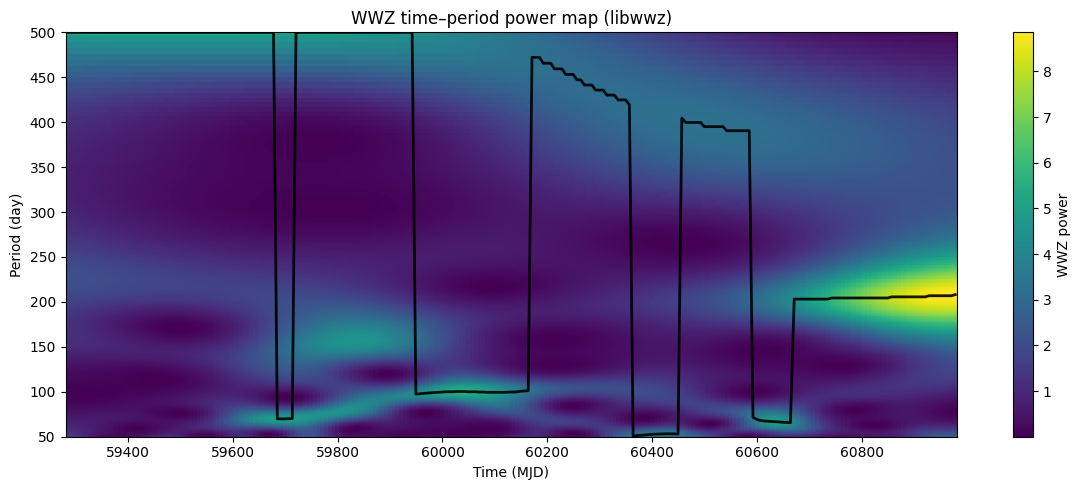

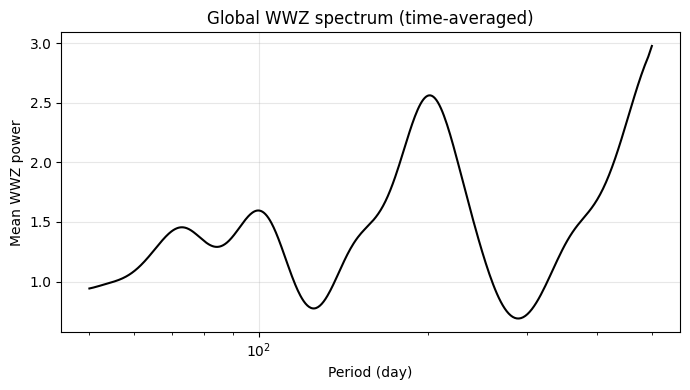

Top 10 ridge peaks (by WWZ power):
 1: tau=  60971.35  period=   206.888  power=       8.854
 2: tau=  60964.20  period=   206.888  power=       8.852
 3: tau=  60978.50  period=   208.159  power=        8.85
 4: tau=  60957.06  period=   206.888  power=       8.844
 5: tau=  60949.91  period=   206.888  power=        8.83
 6: tau=  60942.76  period=   206.888  power=       8.808
 7: tau=  60935.61  period=   206.888  power=       8.779
 8: tau=  60928.47  period=   206.888  power=       8.744
 9: tau=  60921.32  period=   205.632  power=       8.702
10: tau=  60914.17  period=   205.632  power=       8.654


In [6]:
# WWZ
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from libwwz import wwt

# ============================================================
# 0) 读取 LHAASO WCDA Fermi Mrk421 光子计数
# ============================================================
# import numpy as np
# t_mjd = df["mjd"] 
# flux = df["flux_excess"]
# flux_err = df["flux_excess_err"]
# # 去掉 NaN 或 TS 很低的点（如果有的话）
# mask = np.isfinite(flux)
# t_mjd = t_mjd[mask]
# flux  = flux[mask].astype(float)
# flux_err = flux_err[mask].astype(float)

# ============================================================
# 1) 清洗 + 排序 + 合并重复时间（推荐，避免 WWZ/GP 数值问题）
# ============================================================
def clean_and_merge(t, y, yerr):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    yerr = np.asarray(yerr, dtype=float)

    m = np.isfinite(t) & np.isfinite(y) & np.isfinite(yerr) & (yerr > 0)
    t, y, yerr = t[m], y[m], yerr[m]

    s = np.argsort(t)
    t, y, yerr = t[s], y[s], yerr[s]

    uniq_t, idx_start = np.unique(t, return_index=True)
    if len(uniq_t) == len(t):
        return t, y, yerr

    y_new = np.empty_like(uniq_t, dtype=float)
    e_new = np.empty_like(uniq_t, dtype=float)

    for k in range(len(uniq_t)):
        i0 = idx_start[k]
        i1 = idx_start[k+1] if (k+1 < len(uniq_t)) else len(t)
        w = 1.0 / (yerr[i0:i1] ** 2)
        y_new[k] = np.sum(w * y[i0:i1]) / np.sum(w)
        e_new[k] = np.sqrt(1.0 / np.sum(w))

    return uniq_t, y_new, e_new

t, y, yerr = clean_and_merge(t_mjd, flux, flux_err)

Tspan = t.max() - t.min()
dt_med = np.median(np.diff(t))
print(f"N={len(t)}, Tspan={Tspan:.2f} d, dt_med={dt_med:.2f} d")

# ============================================================
# 2) 设定 WWZ 参数（按你的科学问题改这里）
# ============================================================
# 你说你关心 ~300 d 周期，这里给个覆盖范围，比如 150–1000 d
period_min = 50.0
period_max = 500.0
freq_low  = 1.0 / period_max
freq_high = 1.0 / period_min

# 频率步长：经验做法：和总时长成反比
# 步长越小越细，但更慢。可以先粗后细。
freq_step = 0.05 / Tspan

# time_divisions：时间网格数（越大时间分辨率越高，但越慢）
time_divisions = 250

# 衰减常数 c：越大时间定位越强，频率分辨率越差
# 你之前用 0.0125 没问题；周期更长时也可更小一点
decay_constant = 0.0125

print("WWZ settings:")
print(f"  period range: [{period_min}, {period_max}] d")
print(f"  freq range:   [{freq_low:.6g}, {freq_high:.6g}] 1/d")
print(f"  freq_step:    {freq_step:.6g} 1/d")
print(f"  time_divisions: {time_divisions}")
print(f"  decay_constant: {decay_constant}")

# ============================================================
# 3) 计算 WWZ（libwwz）
# ============================================================
out = wwt(
    timestamps=t.astype(float),
    magnitudes=y.astype(float),
    time_divisions=time_divisions,
    freq_params=[freq_low, freq_high, freq_step, True],
    decay_constant=decay_constant,
    method="linear",
    parallel=True
)

tau_mat, freq_mat, wwz_mat, amp_mat, coef_mat, neff_mat = out
period_mat = 1.0 / freq_mat

# ============================================================
# 4) Ridge：每个 tau 上 WWZ 最大对应的 period
# ============================================================
ridge_idx = np.argmax(wwz_mat, axis=1)
ridge_tau = tau_mat[:, 0]
ridge_period = period_mat[np.arange(len(ridge_idx)), ridge_idx]
ridge_power  = wwz_mat[np.arange(len(ridge_idx)), ridge_idx]

# ============================================================
# 5) 作图：光变 + WWZ 时频图 + ridge
# ============================================================
plt.figure(figsize=(12, 4))
plt.errorbar(t, y, yerr=yerr, fmt=".", ms=4, alpha=0.7)
plt.xlabel("Time (MJD)")
plt.ylabel("Flux")
plt.title("Fermi-LAT Mrk421 light curve")
plt.tight_layout()
plt.show()

# 为了让 period 轴递增，我们对列按 period 排序
sort_idx = np.argsort(period_mat[0, :])    # period 递增
tau_plot = tau_mat[:, 0]
period_plot = period_mat[:, sort_idx]
wwz_plot = wwz_mat[:, sort_idx]
p_axis = period_plot[0, :]

plt.figure(figsize=(12, 5))
plt.pcolormesh(tau_plot, p_axis, wwz_plot.T, shading="auto")
plt.xlabel("Time (MJD)")
plt.ylabel("Period (day)")
plt.title("WWZ time–period power map (libwwz)")
cbar = plt.colorbar()
cbar.set_label("WWZ power")

plt.plot(ridge_tau, ridge_period, "k-", lw=2, alpha=0.9)
plt.ylim(period_min, period_max)
plt.tight_layout()
plt.show()

# ============================================================
# 6) （很有用）全局 WWZ spectrum：对时间求平均，看主周期候选
# ============================================================
gwwz = np.nanmean(wwz_mat, axis=0)  # (nfreq,)
period_axis = 1.0 / freq_mat[0, :]

# period 递增排序
p_sort = np.argsort(period_axis)
plt.figure(figsize=(7,4))
plt.plot(period_axis[p_sort], gwwz[p_sort], "k-")
plt.xscale("log")
plt.xlabel("Period (day)")
plt.ylabel("Mean WWZ power")
plt.title("Global WWZ spectrum (time-averaged)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 7) 打印 ridge 的最强若干点（粗看哪些时段最强）
# ============================================================
topk = 10
idx_sorted = np.argsort(ridge_power)[::-1]
print(f"Top {topk} ridge peaks (by WWZ power):")
for k in range(topk):
    i = idx_sorted[k]
    print(f"{k+1:2d}: tau={ridge_tau[i]:10.2f}  period={ridge_period[i]:10.3f}  power={ridge_power[i]:12.4g}")
